# Análisis Exploratorio Bivariado

A continuación se realiza el análisis bivariado del conjunto de datos `diabetes_binary_5050split_health_indicators_BRFSS2015`, tomando como variable de respuesta la condición de diabetes del paciente (`Diabetes`). Se seguirá la misma lógica utilizada en el análisis univariado: primero se comparará la variable de respuesta frente a las variables numéricas (`IMC`, `SaludM`, `SaludF`) mediante gráficos de caja y bigotes, pruebas de normalidad, de igualdad de varianzas y de comparación de medianas/medias entre los dos grupos (con y sin diabetes). Posteriormente se comparará la variable de respuesta frente a cada una de las variables categóricas mediante tablas de contingencia, gráficos de barras agrupadas y la prueba chi-cuadrado de independencia.

## 0. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import anderson, levene, chi2_contingency, mannwhitneyu

sns.set_theme(style='whitegrid')

## 1. Carga y preparación de datos

In [2]:
filename = r"C:\Users\abrah\OneDrive - Universidad del Norte\Documentos\DataViz_2026\python\data\diabetes.csv"

df = pd.read_csv(filename, sep=',')

df = df.rename(columns={
    'Diabetes_binary': 'Diabetes',
    'HighBP':         'PA_alta',
    'HighChol':     'col_alto',
    'CholCheck':   'CheckCol',
    'BMI':  'IMC',
    'Smoker':   'Fumador',
    'Stroke':      'derrame',
    'HeartDiseaseorAttack': 'EnfCardi',
    'PhysActivity':  'ActFisi',
    'Fruits':    'fruta',
    'Veggies':   'vegetales',
    'HvyAlcoholConsump':     'Alcohlico',
    'AnyHealthcare':        'eps',
    'NoDocbcCost':    'AfordabilidadMedica',
    'GenHlth':         'SaludG',
    'MentHlth':        'SaludM',
    'PhysHlth':        'SaludF',
    'DiffWalk':        'DificultadCaminar',
    'Sex': 'Genero',
    'Age': 'Edad',
    'Education': 'Educacion',
    'Income': 'Ingresos'
})[[
    'Diabetes', 'PA_alta', 'col_alto', 'CheckCol',
    'IMC', 'Fumador', 'derrame', 'EnfCardi', 'ActFisi',
    'fruta', 'vegetales', 'Alcohlico', 'eps', 'AfordabilidadMedica',
    'SaludG', 'SaludM', 'SaludF', 'DificultadCaminar', 'Genero',
    'Edad', 'Educacion', 'Ingresos'
]]

df = df.drop_duplicates()
df.head()

,Diabetes,PA_alta,col_alto,CheckCol,IMC,Fumador,derrame,EnfCardi,ActFisi,fruta,...,eps,AfordabilidadMedica,SaludG,SaludM,SaludF,DificultadCaminar,Genero,Edad,Educacion,Ingresos
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [3]:
target = 'Diabetes'
variables_numericas = ['IMC', 'SaludM', 'SaludF']
variables_categoricas = [
    'PA_alta', 'col_alto', 'CheckCol', 'Fumador', 'derrame',
    'EnfCardi', 'ActFisi', 'fruta', 'vegetales', 'Alcohlico',
    'eps', 'AfordabilidadMedica', 'SaludG',
    'DificultadCaminar', 'Genero', 'Edad', 'Educacion', 'Ingresos'
]

paleta = {0.0: '#4C72B0', 1.0: '#DD8452'}
etiquetas_diabetes = {0.0: 'Sin diabetes', 1.0: 'Con diabetes / prediabetes'}

## 2. Variable respuesta frente a variables numéricas

Para cada variable numérica se compararán los dos grupos de la variable de respuesta (`Diabetes` = 0 sin diabetes, `Diabetes` = 1 con diabetes o prediabetes) mediante un gráfico de caja y bigotes bivariado, un resumen descriptivo por grupo, una prueba de normalidad (Anderson-Darling, adecuada para muestras grandes) y una prueba de igualdad de varianzas (Levene). De acuerdo con los resultados de estas dos pruebas se elegirá la prueba de comparación de grupos más apropiada.

### Variable `IMC` (Índice de Masa Corporal)

**Gráfico de caja y bigotes bivariado**

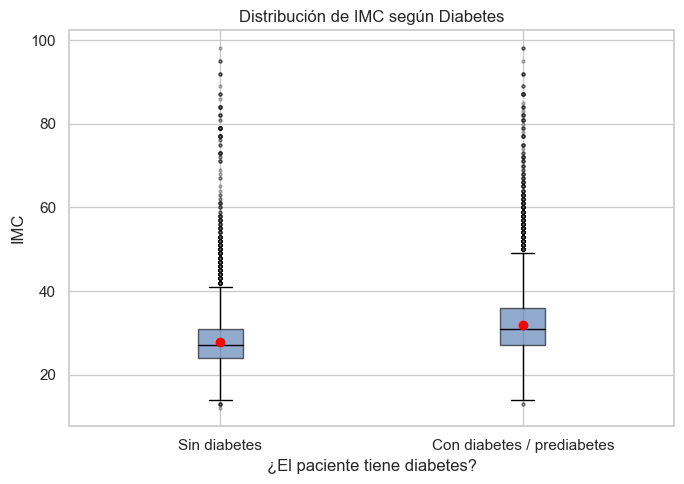

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))

grupos = [df[df[target] == g]['IMC'].dropna() for g in sorted(df[target].unique())]
etiquetas = [etiquetas_diabetes[g] for g in sorted(df[target].unique())]

bp = ax.boxplot(grupos, labels=etiquetas, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6, color='black'),
                medianprops=dict(color='black'),
                flierprops=dict(markerfacecolor='gray', marker='o', markersize=2, alpha=0.3))
for i, g in enumerate(grupos, start=1):
    ax.plot(i, g.mean(), marker='o', color='red', markersize=6, zorder=5)

ax.set_xlabel('¿El paciente tiene diabetes?')
ax.set_ylabel('IMC')
ax.set_title('Distribución de IMC según Diabetes')
plt.tight_layout()
plt.show()

El gráfico muestra que los pacientes con diabetes o prediabetes presentan valores de `IMC` más altos que los pacientes sin diabetes: la media pasa de 27.88 en el grupo sin diabetes a 31.96 en el grupo con diabetes, y la mediana de 27.0 a 31.0. El grupo con diabetes también muestra mayor dispersión (IQR de 9.0 frente a 7.0 en el grupo sin diabetes), lo que sugiere una relación entre esta variable y la condición de diabetes.

**Comparación de ambas muestras**

In [5]:
def resumen(grupo):
    col = grupo['IMC'].dropna()
    return pd.Series({
        'n':          len(col),
        'media':      col.mean(),
        'ds':         col.std(),
        'mediana':    col.median(),
        'minimo':     col.min(),
        'maximo':     col.max(),
        'Q1':         col.quantile(0.25),
        'Q3':         col.quantile(0.75),
        'IQR':        col.quantile(0.75) - col.quantile(0.25)
    })

tabla_grupos = df.groupby(target).apply(resumen).reset_index().rename(columns={target: 'Diabetes'})

col_total = df['IMC'].dropna()
tabla_total = pd.DataFrame([{
    'Diabetes':   'TOTAL',
    'n':          len(col_total),
    'media':      col_total.mean(),
    'ds':         col_total.std(),
    'mediana':    col_total.median(),
    'minimo':     col_total.min(),
    'maximo':     col_total.max(),
    'Q1':         col_total.quantile(0.25),
    'Q3':         col_total.quantile(0.75),
    'IQR':        col_total.quantile(0.75) - col_total.quantile(0.25)
}])
pd.concat([tabla_grupos, tabla_total], ignore_index=True).round(2)

,Diabetes,n,media,ds,mediana,minimo,maximo,Q1,Q3,IQR
0,0.0,33960.0,27.88,6.26,27.0,12.0,98.0,24.0,31.0,7.0
1,1.0,35097.0,31.96,7.38,31.0,13.0,98.0,27.0,36.0,9.0
2,TOTAL,69057.0,29.96,7.15,29.0,12.0,98.0,25.0,33.0,8.0


**Prueba de normalidad (Anderson-Darling)**

In [6]:
grupo_0 = df.loc[df[target] == 0.0, 'IMC'].dropna()
grupo_1 = df.loc[df[target] == 1.0, 'IMC'].dropna()

res_0 = anderson(grupo_0, dist='norm')
res_1 = anderson(grupo_1, dist='norm')

print("Anderson-Darling: Sin diabetes")
print(f"Estadístico: {res_0.statistic:.4f}")
print(f"Valor crítico al 5%: {res_0.critical_values[2]:.4f}")
print(f"Resultado: {'Rechaza H0 (no normal)' if res_0.statistic > res_0.critical_values[2] else 'No rechaza H0'}")

print("\nAnderson-Darling: Con diabetes")
print(f"Estadístico: {res_1.statistic:.4f}")
print(f"Valor crítico al 5%: {res_1.critical_values[2]:.4f}")
print(f"Resultado: {'Rechaza H0 (no normal)' if res_1.statistic > res_1.critical_values[2] else 'No rechaza H0'}")

Anderson-Darling: Sin diabetes
Estadístico: 640.0333
Valor crítico al 5%: 0.7520
Resultado: Rechaza H0 (no normal)

Anderson-Darling: Con diabetes
Estadístico: 519.7446
Valor crítico al 5%: 0.7520
Resultado: Rechaza H0 (no normal)


/tmp/ipykernel_589/3765622152.py:4: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res_0 = anderson(grupo_0, dist='norm')
/tmp/ipykernel_589/3765622152.py:5: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate th

Con un nivel de confianza del 95%, el estadístico de Anderson-Darling (640.03 en el grupo sin diabetes y 519.74 en el grupo con diabetes) supera ampliamente el valor crítico (0.752) en ambos grupos, por lo que se rechaza la hipótesis de normalidad en los dos casos. Esto es consistente con lo observado en el análisis univariado, donde `IMC` ya mostraba una distribución alejada de la normal.

**Prueba de igualdad de varianzas (Levene)**

In [7]:
lev_stat, lev_p = levene(grupo_0, grupo_1)
print(f"Estadístico de Levene: {lev_stat:.4f}")
print(f"p-valor: {lev_p:.4e}")
print(f"Resultado: {'Rechaza H0 (varianzas distintas)' if lev_p < 0.05 else 'No rechaza H0 (varianzas iguales)'}")

Estadístico de Levene: 796.6615
p-valor: 2.8228e-174
Resultado: Rechaza H0 (varianzas distintas)


La prueba de Levene arroja un estadístico de 796.66 con un p-valor de 2.823e-174, menor a 0.05, por lo que se rechaza la hipótesis de igualdad de varianzas entre los dos grupos.

**Prueba de Mann-Whitney (Wilcoxon rank-sum)**

Dado que ninguno de los dos grupos sigue una distribución normal, se utiliza la prueba de Mann-Whitney U (equivalente no paramétrico de la prueba t), adecuada para comparar dos muestras independientes que no cumplen el supuesto de normalidad.

In [8]:
stat, p = mannwhitneyu(grupo_1, grupo_0, alternative='two-sided')

print("Mann-Whitney U (Wilcoxon rank-sum)")
print(f"Estadístico U: {stat:.4f}")
print(f"p-valor: {p:.6e}")
print(f"Resultado: {'Rechaza H0 (distribuciones distintas)' if p < 0.05 else 'No rechaza H0'}")

Mann-Whitney U (Wilcoxon rank-sum)
Estadístico U: 815513028.5000
p-valor: 0.000000e+00
Resultado: Rechaza H0 (distribuciones distintas)


La prueba de Mann-Whitney arrojó un p-valor menor a 0.001, lo que indica que se rechaza la hipótesis nula de igualdad en la distribución de `IMC` entre los pacientes con y sin diabetes. En consecuencia, existe una diferencia estadísticamente significativa entre ambos grupos, lo que constituye un indicio de dependencia entre `IMC` y la variable de respuesta.

### Variable `SaludM` (días de salud mental no buena en los últimos 30 días)

**Gráfico de caja y bigotes bivariado**

/tmp/ipykernel_589/759928918.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grupos, labels=etiquetas, patch_artist=True,


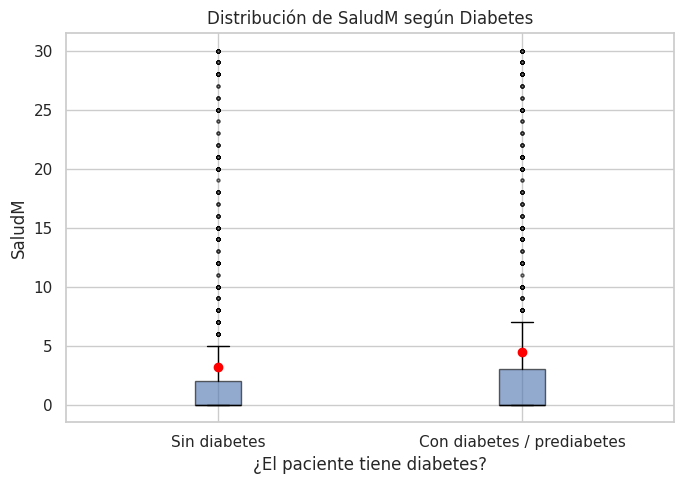

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

grupos = [df[df[target] == g]['SaludM'].dropna() for g in sorted(df[target].unique())]
etiquetas = [etiquetas_diabetes[g] for g in sorted(df[target].unique())]

bp = ax.boxplot(grupos, labels=etiquetas, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6, color='black'),
                medianprops=dict(color='black'),
                flierprops=dict(markerfacecolor='gray', marker='o', markersize=2, alpha=0.3))
for i, g in enumerate(grupos, start=1):
    ax.plot(i, g.mean(), marker='o', color='red', markersize=6, zorder=5)

ax.set_xlabel('¿El paciente tiene diabetes?')
ax.set_ylabel('SaludM')
ax.set_title('Distribución de SaludM según Diabetes')
plt.tight_layout()
plt.show()

El gráfico muestra que los pacientes con diabetes o prediabetes presentan valores de `SaludM` más altos que los pacientes sin diabetes: la media pasa de 3.16 en el grupo sin diabetes a 4.49 en el grupo con diabetes, y la mediana de 0.0 a 0.0. El grupo con diabetes también muestra mayor dispersión (IQR de 3.0 frente a 2.0 en el grupo sin diabetes), lo que sugiere una relación entre esta variable y la condición de diabetes.

**Comparación de ambas muestras**

In [10]:
def resumen(grupo):
    col = grupo['SaludM'].dropna()
    return pd.Series({
        'n':          len(col),
        'media':      col.mean(),
        'ds':         col.std(),
        'mediana':    col.median(),
        'minimo':     col.min(),
        'maximo':     col.max(),
        'Q1':         col.quantile(0.25),
        'Q3':         col.quantile(0.75),
        'IQR':        col.quantile(0.75) - col.quantile(0.25)
    })

tabla_grupos = df.groupby(target).apply(resumen).reset_index().rename(columns={target: 'Diabetes'})

col_total = df['SaludM'].dropna()
tabla_total = pd.DataFrame([{
    'Diabetes':   'TOTAL',
    'n':          len(col_total),
    'media':      col_total.mean(),
    'ds':         col_total.std(),
    'mediana':    col_total.median(),
    'minimo':     col_total.min(),
    'maximo':     col_total.max(),
    'Q1':         col_total.quantile(0.25),
    'Q3':         col_total.quantile(0.75),
    'IQR':        col_total.quantile(0.75) - col_total.quantile(0.25)
}])
pd.concat([tabla_grupos, tabla_total], ignore_index=True).round(2)

,Diabetes,n,media,ds,mediana,minimo,maximo,Q1,Q3,IQR
0,0.0,33960.0,3.16,7.33,0.0,0.0,30.0,0.0,2.0,2.0
1,1.0,35097.0,4.49,8.97,0.0,0.0,30.0,0.0,3.0,3.0
2,TOTAL,69057.0,3.84,8.23,0.0,0.0,30.0,0.0,3.0,3.0


**Prueba de normalidad (Anderson-Darling)**

In [11]:
grupo_0 = df.loc[df[target] == 0.0, 'SaludM'].dropna()
grupo_1 = df.loc[df[target] == 1.0, 'SaludM'].dropna()

res_0 = anderson(grupo_0, dist='norm')
res_1 = anderson(grupo_1, dist='norm')

print("Anderson-Darling: Sin diabetes")
print(f"Estadístico: {res_0.statistic:.4f}")
print(f"Valor crítico al 5%: {res_0.critical_values[2]:.4f}")
print(f"Resultado: {'Rechaza H0 (no normal)' if res_0.statistic > res_0.critical_values[2] else 'No rechaza H0'}")

print("\nAnderson-Darling: Con diabetes")
print(f"Estadístico: {res_1.statistic:.4f}")
print(f"Valor crítico al 5%: {res_1.critical_values[2]:.4f}")
print(f"Resultado: {'Rechaza H0 (no normal)' if res_1.statistic > res_1.critical_values[2] else 'No rechaza H0'}")

Anderson-Darling: Sin diabetes
Estadístico: 7261.1022
Valor crítico al 5%: 0.7520
Resultado: Rechaza H0 (no normal)

Anderson-Darling: Con diabetes
Estadístico: 6930.6503
Valor crítico al 5%: 0.7520
Resultado: Rechaza H0 (no normal)


/tmp/ipykernel_589/3129898607.py:4: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res_0 = anderson(grupo_0, dist='norm')
/tmp/ipykernel_589/3129898607.py:5: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate th

Con un nivel de confianza del 95%, el estadístico de Anderson-Darling (7261.10 en el grupo sin diabetes y 6930.65 en el grupo con diabetes) supera ampliamente el valor crítico (0.752) en ambos grupos, por lo que se rechaza la hipótesis de normalidad en los dos casos. Esto es consistente con lo observado en el análisis univariado, donde `SaludM` ya mostraba una distribución alejada de la normal.

**Prueba de igualdad de varianzas (Levene)**

In [12]:
lev_stat, lev_p = levene(grupo_0, grupo_1)
print(f"Estadístico de Levene: {lev_stat:.4f}")
print(f"p-valor: {lev_p:.4e}")
print(f"Resultado: {'Rechaza H0 (varianzas distintas)' if lev_p < 0.05 else 'No rechaza H0 (varianzas iguales)'}")

Estadístico de Levene: 452.5269
p-valor: 4.2676e-100
Resultado: Rechaza H0 (varianzas distintas)


La prueba de Levene arroja un estadístico de 452.53 con un p-valor de 4.268e-100, menor a 0.05, por lo que se rechaza la hipótesis de igualdad de varianzas entre los dos grupos.

**Prueba de Mann-Whitney (Wilcoxon rank-sum)**

Dado que ninguno de los dos grupos sigue una distribución normal, se utiliza la prueba de Mann-Whitney U (equivalente no paramétrico de la prueba t), adecuada para comparar dos muestras independientes que no cumplen el supuesto de normalidad.

In [13]:
stat, p = mannwhitneyu(grupo_1, grupo_0, alternative='two-sided')

print("Mann-Whitney U (Wilcoxon rank-sum)")
print(f"Estadístico U: {stat:.4f}")
print(f"p-valor: {p:.6e}")
print(f"Resultado: {'Rechaza H0 (distribuciones distintas)' if p < 0.05 else 'No rechaza H0'}")

Mann-Whitney U (Wilcoxon rank-sum)
Estadístico U: 623076966.0000
p-valor: 1.791576e-35
Resultado: Rechaza H0 (distribuciones distintas)


La prueba de Mann-Whitney arrojó un p-valor menor a 0.001, lo que indica que se rechaza la hipótesis nula de igualdad en la distribución de `SaludM` entre los pacientes con y sin diabetes. En consecuencia, existe una diferencia estadísticamente significativa entre ambos grupos, lo que constituye un indicio de dependencia entre `SaludM` y la variable de respuesta.

### Variable `SaludF` (días de salud física no buena en los últimos 30 días)

**Gráfico de caja y bigotes bivariado**

/tmp/ipykernel_589/2621245245.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grupos, labels=etiquetas, patch_artist=True,


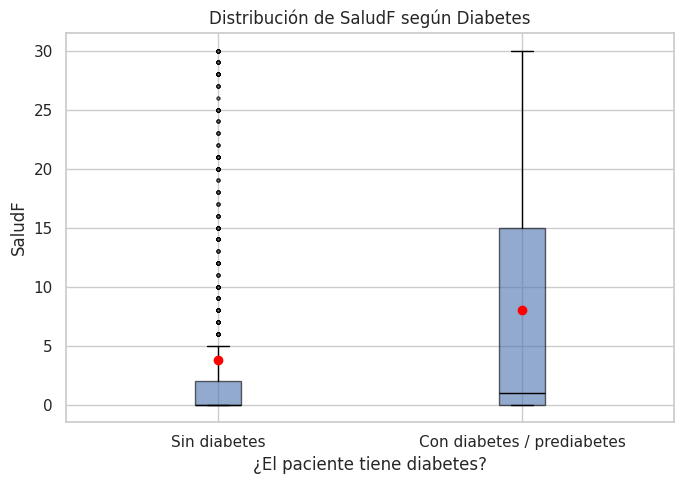

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

grupos = [df[df[target] == g]['SaludF'].dropna() for g in sorted(df[target].unique())]
etiquetas = [etiquetas_diabetes[g] for g in sorted(df[target].unique())]

bp = ax.boxplot(grupos, labels=etiquetas, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6, color='black'),
                medianprops=dict(color='black'),
                flierprops=dict(markerfacecolor='gray', marker='o', markersize=2, alpha=0.3))
for i, g in enumerate(grupos, start=1):
    ax.plot(i, g.mean(), marker='o', color='red', markersize=6, zorder=5)

ax.set_xlabel('¿El paciente tiene diabetes?')
ax.set_ylabel('SaludF')
ax.set_title('Distribución de SaludF según Diabetes')
plt.tight_layout()
plt.show()

El gráfico muestra que los pacientes con diabetes o prediabetes presentan valores de `SaludF` más altos que los pacientes sin diabetes: la media pasa de 3.81 en el grupo sin diabetes a 8.01 en el grupo con diabetes, y la mediana de 0.0 a 1.0. El grupo con diabetes también muestra mayor dispersión (IQR de 15.0 frente a 2.0 en el grupo sin diabetes), lo que sugiere una relación entre esta variable y la condición de diabetes.

**Comparación de ambas muestras**

In [15]:
def resumen(grupo):
    col = grupo['SaludF'].dropna()
    return pd.Series({
        'n':          len(col),
        'media':      col.mean(),
        'ds':         col.std(),
        'mediana':    col.median(),
        'minimo':     col.min(),
        'maximo':     col.max(),
        'Q1':         col.quantile(0.25),
        'Q3':         col.quantile(0.75),
        'IQR':        col.quantile(0.75) - col.quantile(0.25)
    })

tabla_grupos = df.groupby(target).apply(resumen).reset_index().rename(columns={target: 'Diabetes'})

col_total = df['SaludF'].dropna()
tabla_total = pd.DataFrame([{
    'Diabetes':   'TOTAL',
    'n':          len(col_total),
    'media':      col_total.mean(),
    'ds':         col_total.std(),
    'mediana':    col_total.median(),
    'minimo':     col_total.min(),
    'maximo':     col_total.max(),
    'Q1':         col_total.quantile(0.25),
    'Q3':         col_total.quantile(0.75),
    'IQR':        col_total.quantile(0.75) - col_total.quantile(0.25)
}])
pd.concat([tabla_grupos, tabla_total], ignore_index=True).round(2)

,Diabetes,n,media,ds,mediana,minimo,maximo,Q1,Q3,IQR
0,0.0,33960.0,3.81,8.23,0.0,0.0,30.0,0.0,2.0,2.0
1,1.0,35097.0,8.01,11.32,1.0,0.0,30.0,0.0,15.0,15.0
2,TOTAL,69057.0,5.95,10.14,0.0,0.0,30.0,0.0,6.0,6.0


**Prueba de normalidad (Anderson-Darling)**

In [16]:
grupo_0 = df.loc[df[target] == 0.0, 'SaludF'].dropna()
grupo_1 = df.loc[df[target] == 1.0, 'SaludF'].dropna()

res_0 = anderson(grupo_0, dist='norm')
res_1 = anderson(grupo_1, dist='norm')

print("Anderson-Darling: Sin diabetes")
print(f"Estadístico: {res_0.statistic:.4f}")
print(f"Valor crítico al 5%: {res_0.critical_values[2]:.4f}")
print(f"Resultado: {'Rechaza H0 (no normal)' if res_0.statistic > res_0.critical_values[2] else 'No rechaza H0'}")

print("\nAnderson-Darling: Con diabetes")
print(f"Estadístico: {res_1.statistic:.4f}")
print(f"Valor crítico al 5%: {res_1.critical_values[2]:.4f}")
print(f"Resultado: {'Rechaza H0 (no normal)' if res_1.statistic > res_1.critical_values[2] else 'No rechaza H0'}")

Anderson-Darling: Sin diabetes
Estadístico: 7031.1427
Valor crítico al 5%: 0.7520
Resultado: Rechaza H0 (no normal)

Anderson-Darling: Con diabetes
Estadístico: 4639.2176
Valor crítico al 5%: 0.7520
Resultado: Rechaza H0 (no normal)


/tmp/ipykernel_589/233675159.py:4: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  res_0 = anderson(grupo_0, dist='norm')
/tmp/ipykernel_589/233675159.py:5: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the 

Con un nivel de confianza del 95%, el estadístico de Anderson-Darling (7031.14 en el grupo sin diabetes y 4639.22 en el grupo con diabetes) supera ampliamente el valor crítico (0.752) en ambos grupos, por lo que se rechaza la hipótesis de normalidad en los dos casos. Esto es consistente con lo observado en el análisis univariado, donde `SaludF` ya mostraba una distribución alejada de la normal.

**Prueba de igualdad de varianzas (Levene)**

In [17]:
lev_stat, lev_p = levene(grupo_0, grupo_1)
print(f"Estadístico de Levene: {lev_stat:.4f}")
print(f"p-valor: {lev_p:.4e}")
print(f"Resultado: {'Rechaza H0 (varianzas distintas)' if lev_p < 0.05 else 'No rechaza H0 (varianzas iguales)'}")

Estadístico de Levene: 3234.6233
p-valor: 0.0000e+00
Resultado: Rechaza H0 (varianzas distintas)


La prueba de Levene arroja un estadístico de 3234.62 con un p-valor de 0.000e+00, menor a 0.05, por lo que se rechaza la hipótesis de igualdad de varianzas entre los dos grupos.

**Prueba de Mann-Whitney (Wilcoxon rank-sum)**

Dado que ninguno de los dos grupos sigue una distribución normal, se utiliza la prueba de Mann-Whitney U (equivalente no paramétrico de la prueba t), adecuada para comparar dos muestras independientes que no cumplen el supuesto de normalidad.

In [18]:
stat, p = mannwhitneyu(grupo_1, grupo_0, alternative='two-sided')

print("Mann-Whitney U (Wilcoxon rank-sum)")
print(f"Estadístico U: {stat:.4f}")
print(f"p-valor: {p:.6e}")
print(f"Resultado: {'Rechaza H0 (distribuciones distintas)' if p < 0.05 else 'No rechaza H0'}")

Mann-Whitney U (Wilcoxon rank-sum)
Estadístico U: 725339035.0000
p-valor: 0.000000e+00
Resultado: Rechaza H0 (distribuciones distintas)


La prueba de Mann-Whitney arrojó un p-valor menor a 0.001, lo que indica que se rechaza la hipótesis nula de igualdad en la distribución de `SaludF` entre los pacientes con y sin diabetes. En consecuencia, existe una diferencia estadísticamente significativa entre ambos grupos, lo que constituye un indicio de dependencia entre `SaludF` y la variable de respuesta.

## 3. Variable respuesta frente a variables categóricas

Para cada variable categórica se construirá una tabla de frecuencias y porcentajes por grupo de `Diabetes`, un gráfico de barras agrupadas y la prueba chi-cuadrado de independencia para evaluar si existe asociación entre dicha variable y la condición de diabetes.

### Variable `PA_alta` (presión arterial alta)

**Tabla de frecuencias por grupo**

In [19]:
tabla_PA_alta = (
    df.groupby(target)['PA_alta']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'PA_alta': 'categoria'})
)
tabla_PA_alta['porcentaje'] = tabla_PA_alta.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_PA_alta = tabla_PA_alta.sort_values([target, 'n'], ascending=[True, False])
tabla_PA_alta

,Diabetes,categoria,n,porcentaje
0,0.0,0.0,20918,61.60
1,0.0,1.0,13042,38.40
2,1.0,1.0,26405,75.23
3,1.0,0.0,8692,24.77


**Gráfico de barras agrupadas**

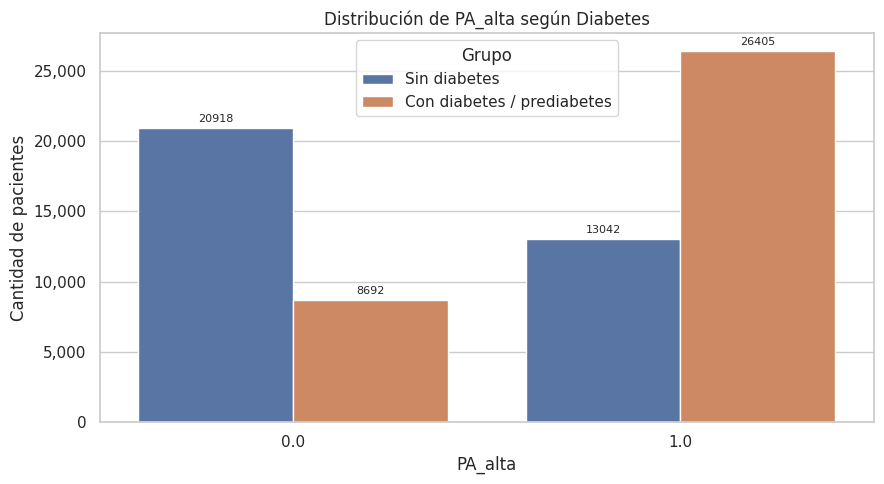

In [20]:
df_plot = tabla_PA_alta.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de PA_alta según Diabetes')
plt.xlabel('PA_alta')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `PA_alta` es No (61.6%), mientras que en el grupo con diabetes la más frecuente es Sí (75.2%). La proporción de pacientes en la categoría 'Sí' (o equivalente) es de 38.4% en el grupo sin diabetes frente a 75.2% en el grupo con diabetes, lo que evidencia una diferencia entre ambos grupos.

**Prueba de independencia (chi-cuadrado)**

In [21]:
tabla_chi = pd.crosstab(df['PA_alta'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 9557.3231
p-valor:        0.0000e+00
Grados de libertad: 1
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `PA_alta` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(1)}$ = 9557.32, p-valor < 0.001).

### Variable `col_alto` (colesterol alto)

**Tabla de frecuencias por grupo**

In [22]:
tabla_col_alto = (
    df.groupby(target)['col_alto']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'col_alto': 'categoria'})
)
tabla_col_alto['porcentaje'] = tabla_col_alto.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_col_alto = tabla_col_alto.sort_values([target, 'n'], ascending=[True, False])
tabla_col_alto

,Diabetes,categoria,n,porcentaje
0,0.0,0.0,20764,61.14
1,0.0,1.0,13196,38.86
2,1.0,1.0,23496,66.95
3,1.0,0.0,11601,33.05


**Gráfico de barras agrupadas**

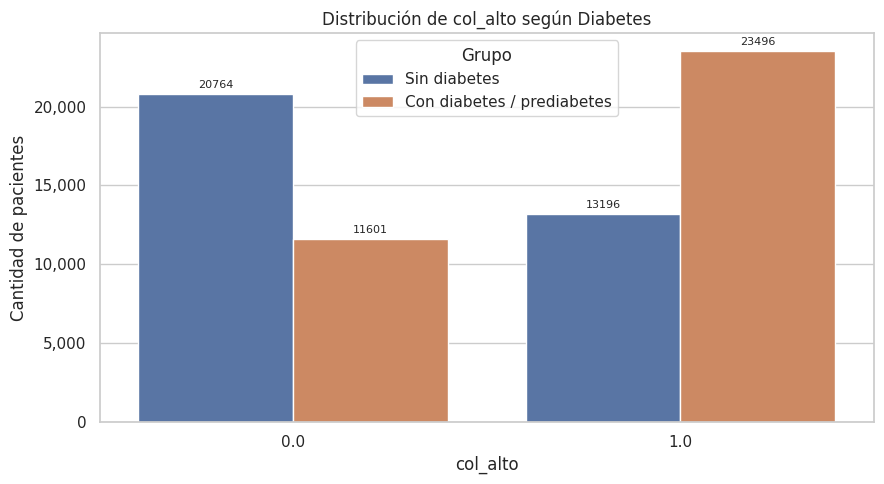

In [23]:
df_plot = tabla_col_alto.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de col_alto según Diabetes')
plt.xlabel('col_alto')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `col_alto` es No (61.1%), mientras que en el grupo con diabetes la más frecuente es Sí (67.0%). La proporción de pacientes en la categoría 'Sí' (o equivalente) es de 38.9% en el grupo sin diabetes frente a 67.0% en el grupo con diabetes, lo que evidencia una diferencia entre ambos grupos.

**Prueba de independencia (chi-cuadrado)**

In [24]:
tabla_chi = pd.crosstab(df['col_alto'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 5467.1781
p-valor:        0.0000e+00
Grados de libertad: 1
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `col_alto` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(1)}$ = 5467.18, p-valor < 0.001).

### Variable `CheckCol` (chequeo de colesterol en los últimos 5 años)

**Tabla de frecuencias por grupo**

In [25]:
tabla_CheckCol = (
    df.groupby(target)['CheckCol']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'CheckCol': 'categoria'})
)
tabla_CheckCol['porcentaje'] = tabla_CheckCol.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_CheckCol = tabla_CheckCol.sort_values([target, 'n'], ascending=[True, False])
tabla_CheckCol

,Diabetes,categoria,n,porcentaje
0,0.0,1.0,32461,95.59
1,0.0,0.0,1499,4.41
2,1.0,1.0,34856,99.31
3,1.0,0.0,241,0.69


**Gráfico de barras agrupadas**

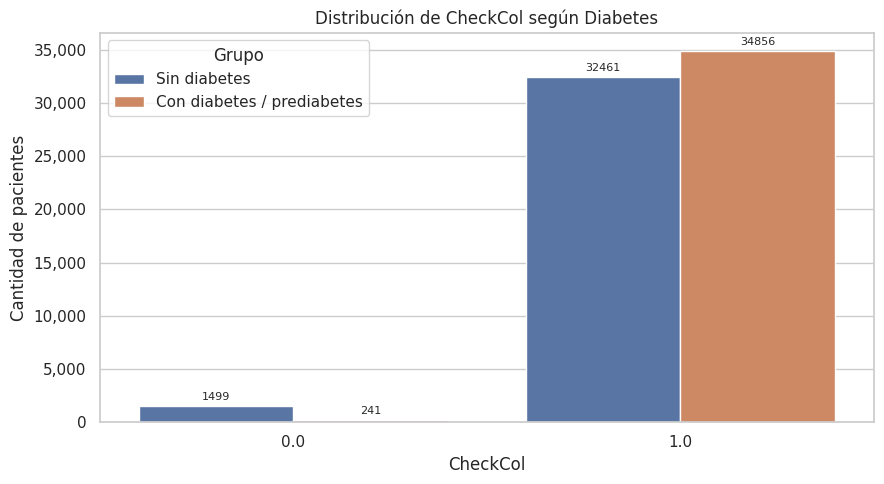

In [26]:
df_plot = tabla_CheckCol.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de CheckCol según Diabetes')
plt.xlabel('CheckCol')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `CheckCol` es Sí (95.6%), mientras que en el grupo con diabetes la más frecuente es Sí (99.3%). La proporción de pacientes en la categoría 'Sí' (o equivalente) es de 95.6% en el grupo sin diabetes frente a 99.3% en el grupo con diabetes, lo que evidencia una diferencia entre ambos grupos.

**Prueba de independencia (chi-cuadrado)**

In [27]:
tabla_chi = pd.crosstab(df['CheckCol'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 974.7561
p-valor:        5.5138e-214
Grados de libertad: 1
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `CheckCol` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(1)}$ = 974.76, p-valor < 0.001).

### Variable `Fumador` (haber fumado al menos 100 cigarrillos en la vida)

**Tabla de frecuencias por grupo**

In [28]:
tabla_Fumador = (
    df.groupby(target)['Fumador']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'Fumador': 'categoria'})
)
tabla_Fumador['porcentaje'] = tabla_Fumador.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_Fumador = tabla_Fumador.sort_values([target, 'n'], ascending=[True, False])
tabla_Fumador

,Diabetes,categoria,n,porcentaje
0,0.0,0.0,18902,55.66
1,0.0,1.0,15058,44.34
2,1.0,1.0,18223,51.92
3,1.0,0.0,16874,48.08


**Gráfico de barras agrupadas**

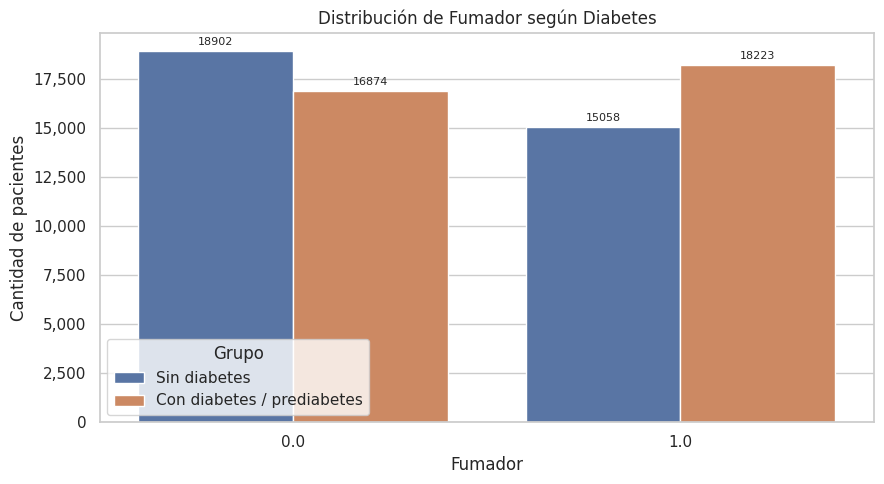

In [29]:
df_plot = tabla_Fumador.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de Fumador según Diabetes')
plt.xlabel('Fumador')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `Fumador` es No (55.7%), mientras que en el grupo con diabetes la más frecuente es Sí (51.9%). La proporción de pacientes en la categoría 'Sí' (o equivalente) es de 44.3% en el grupo sin diabetes frente a 51.9% en el grupo con diabetes, lo que evidencia una diferencia entre ambos grupos.

**Prueba de independencia (chi-cuadrado)**

In [30]:
tabla_chi = pd.crosstab(df['Fumador'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 397.0324
p-valor:        2.4375e-88
Grados de libertad: 1
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `Fumador` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(1)}$ = 397.03, p-valor < 0.001).

### Variable `derrame` (haber tenido un derrame cerebral)

**Tabla de frecuencias por grupo**

In [31]:
tabla_derrame = (
    df.groupby(target)['derrame']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'derrame': 'categoria'})
)
tabla_derrame['porcentaje'] = tabla_derrame.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_derrame = tabla_derrame.sort_values([target, 'n'], ascending=[True, False])
tabla_derrame

,Diabetes,categoria,n,porcentaje
0,0.0,0.0,32833,96.68
1,0.0,1.0,1127,3.32
2,1.0,0.0,31829,90.69
3,1.0,1.0,3268,9.31


**Gráfico de barras agrupadas**

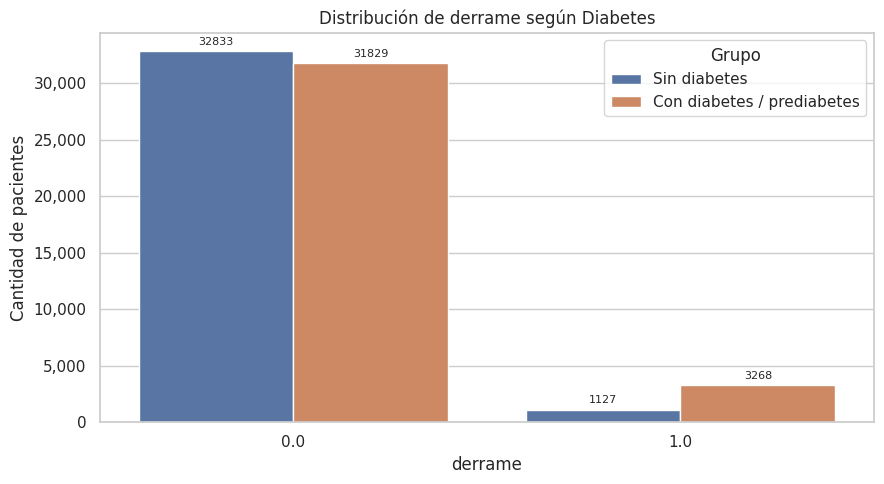

In [32]:
df_plot = tabla_derrame.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de derrame según Diabetes')
plt.xlabel('derrame')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `derrame` es No (96.7%), mientras que en el grupo con diabetes la más frecuente es No (90.7%). La proporción de pacientes en la categoría 'Sí' (o equivalente) es de 3.3% en el grupo sin diabetes frente a 9.3% en el grupo con diabetes, lo que evidencia una diferencia entre ambos grupos.

**Prueba de independencia (chi-cuadrado)**

In [33]:
tabla_chi = pd.crosstab(df['derrame'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 1039.1216
p-valor:        5.6338e-228
Grados de libertad: 1
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `derrame` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(1)}$ = 1039.12, p-valor < 0.001).

### Variable `EnfCardi` (enfermedad coronaria o infarto)

**Tabla de frecuencias por grupo**

In [34]:
tabla_EnfCardi = (
    df.groupby(target)['EnfCardi']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'EnfCardi': 'categoria'})
)
tabla_EnfCardi['porcentaje'] = tabla_EnfCardi.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_EnfCardi = tabla_EnfCardi.sort_values([target, 'n'], ascending=[True, False])
tabla_EnfCardi

,Diabetes,categoria,n,porcentaje
0,0.0,0.0,31397,92.45
1,0.0,1.0,2563,7.55
2,1.0,0.0,27241,77.62
3,1.0,1.0,7856,22.38


**Gráfico de barras agrupadas**

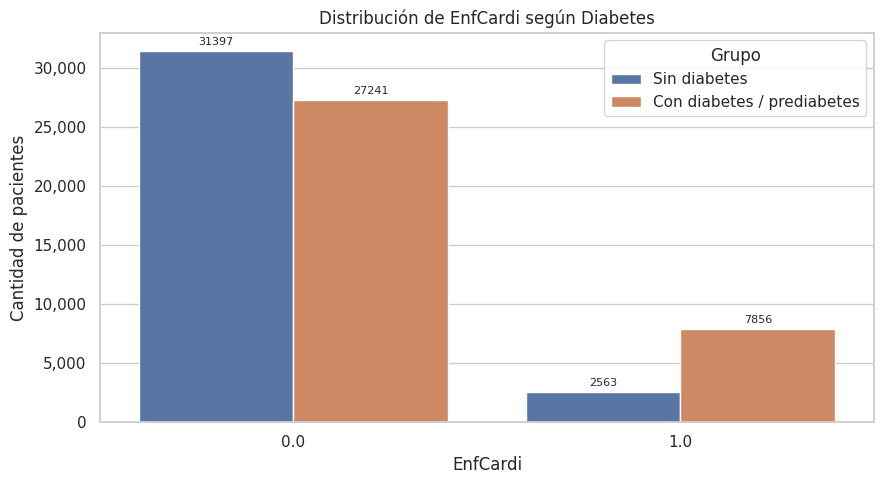

In [35]:
df_plot = tabla_EnfCardi.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de EnfCardi según Diabetes')
plt.xlabel('EnfCardi')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `EnfCardi` es No (92.5%), mientras que en el grupo con diabetes la más frecuente es No (77.6%). La proporción de pacientes en la categoría 'Sí' (o equivalente) es de 7.5% en el grupo sin diabetes frente a 22.4% en el grupo con diabetes, lo que evidencia una diferencia entre ambos grupos.

**Prueba de independencia (chi-cuadrado)**

In [36]:
tabla_chi = pd.crosstab(df['EnfCardi'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 2964.4036
p-valor:        0.0000e+00
Grados de libertad: 1
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `EnfCardi` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(1)}$ = 2964.40, p-valor < 0.001).

### Variable `ActFisi` (actividad física en los últimos 30 días)

**Tabla de frecuencias por grupo**

In [37]:
tabla_ActFisi = (
    df.groupby(target)['ActFisi']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'ActFisi': 'categoria'})
)
tabla_ActFisi['porcentaje'] = tabla_ActFisi.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_ActFisi = tabla_ActFisi.sort_values([target, 'n'], ascending=[True, False])
tabla_ActFisi

,Diabetes,categoria,n,porcentaje
0,0.0,1.0,26038,76.67
1,0.0,0.0,7922,23.33
2,1.0,1.0,22059,62.85
3,1.0,0.0,13038,37.15


**Gráfico de barras agrupadas**

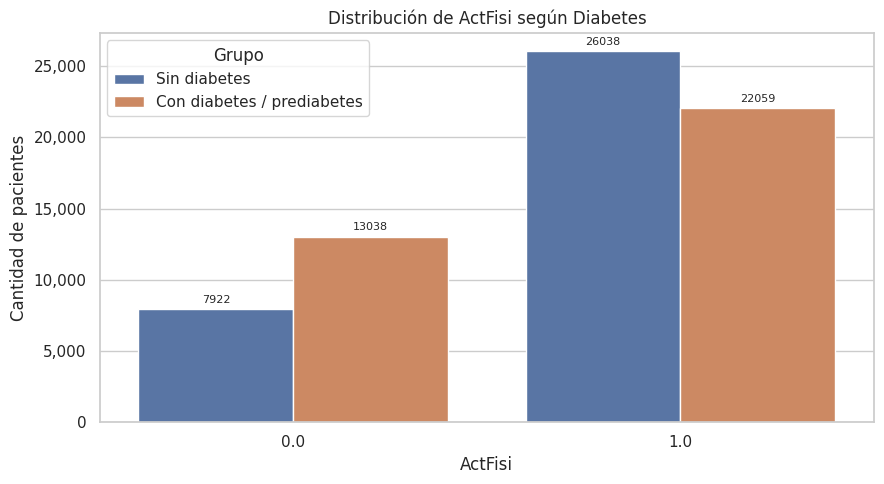

In [38]:
df_plot = tabla_ActFisi.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de ActFisi según Diabetes')
plt.xlabel('ActFisi')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `ActFisi` es Sí (76.7%), mientras que en el grupo con diabetes la más frecuente es Sí (62.9%). La proporción de pacientes en la categoría 'Sí' (o equivalente) es de 76.7% en el grupo sin diabetes frente a 62.9% en el grupo con diabetes, lo que evidencia una diferencia entre ambos grupos.

**Prueba de independencia (chi-cuadrado)**

In [39]:
tabla_chi = pd.crosstab(df['ActFisi'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 1558.9596
p-valor:        0.0000e+00
Grados de libertad: 1
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `ActFisi` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(1)}$ = 1558.96, p-valor < 0.001).

### Variable `fruta` (consumo de fruta al menos una vez al día)

**Tabla de frecuencias por grupo**

In [40]:
tabla_fruta = (
    df.groupby(target)['fruta']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'fruta': 'categoria'})
)
tabla_fruta['porcentaje'] = tabla_fruta.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_fruta = tabla_fruta.sort_values([target, 'n'], ascending=[True, False])
tabla_fruta

,Diabetes,categoria,n,porcentaje
0,0.0,1.0,21320,62.78
1,0.0,0.0,12640,37.22
2,1.0,1.0,20505,58.42
3,1.0,0.0,14592,41.58


**Gráfico de barras agrupadas**

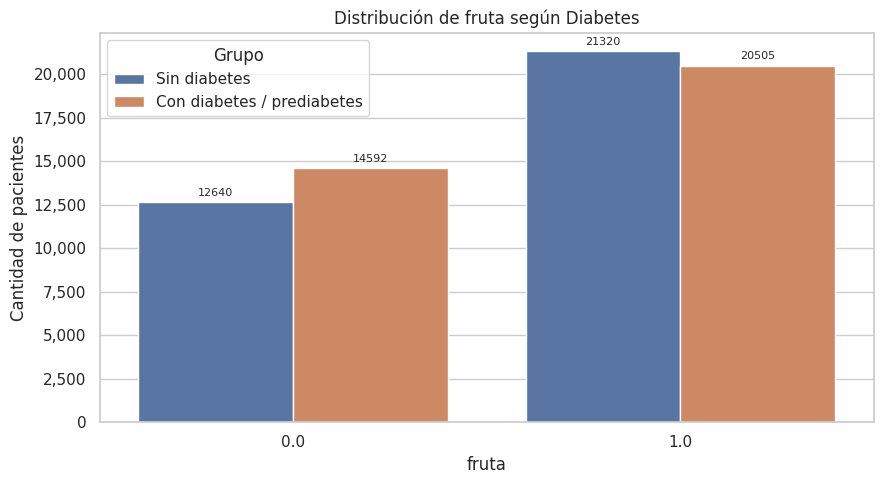

In [41]:
df_plot = tabla_fruta.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de fruta según Diabetes')
plt.xlabel('fruta')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `fruta` es Sí (62.8%), mientras que en el grupo con diabetes la más frecuente es Sí (58.4%). La proporción de pacientes en la categoría 'Sí' (o equivalente) es de 62.8% en el grupo sin diabetes frente a 58.4% en el grupo con diabetes, lo que evidencia una diferencia entre ambos grupos.

**Prueba de independencia (chi-cuadrado)**

In [42]:
tabla_chi = pd.crosstab(df['fruta'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 136.9357
p-valor:        1.2456e-31
Grados de libertad: 1
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `fruta` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(1)}$ = 136.94, p-valor < 0.001).

### Variable `vegetales` (consumo de vegetales al menos una vez al día)

**Tabla de frecuencias por grupo**

In [43]:
tabla_vegetales = (
    df.groupby(target)['vegetales']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'vegetales': 'categoria'})
)
tabla_vegetales['porcentaje'] = tabla_vegetales.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_vegetales = tabla_vegetales.sort_values([target, 'n'], ascending=[True, False])
tabla_vegetales

,Diabetes,categoria,n,porcentaje
0,0.0,1.0,27654,81.43
1,0.0,0.0,6306,18.57
2,1.0,1.0,26495,75.49
3,1.0,0.0,8602,24.51


**Gráfico de barras agrupadas**

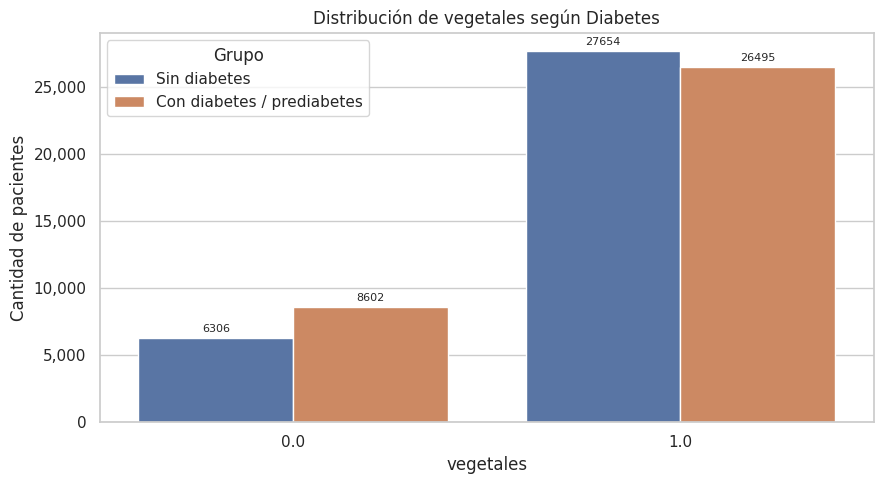

In [44]:
df_plot = tabla_vegetales.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de vegetales según Diabetes')
plt.xlabel('vegetales')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `vegetales` es Sí (81.4%), mientras que en el grupo con diabetes la más frecuente es Sí (75.5%). La proporción de pacientes en la categoría 'Sí' (o equivalente) es de 81.4% en el grupo sin diabetes frente a 75.5% en el grupo con diabetes, lo que evidencia una diferencia entre ambos grupos.

**Prueba de independencia (chi-cuadrado)**

In [45]:
tabla_chi = pd.crosstab(df['vegetales'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 359.4434
p-valor:        3.7221e-80
Grados de libertad: 1
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `vegetales` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(1)}$ = 359.44, p-valor < 0.001).

### Variable `Alcohlico` (consumo excesivo de alcohol)

**Tabla de frecuencias por grupo**

In [46]:
tabla_Alcohlico = (
    df.groupby(target)['Alcohlico']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'Alcohlico': 'categoria'})
)
tabla_Alcohlico['porcentaje'] = tabla_Alcohlico.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_Alcohlico = tabla_Alcohlico.sort_values([target, 'n'], ascending=[True, False])
tabla_Alcohlico

,Diabetes,categoria,n,porcentaje
0,0.0,0.0,31787,93.60
1,0.0,1.0,2173,6.40
2,1.0,0.0,34265,97.63
3,1.0,1.0,832,2.37


**Gráfico de barras agrupadas**

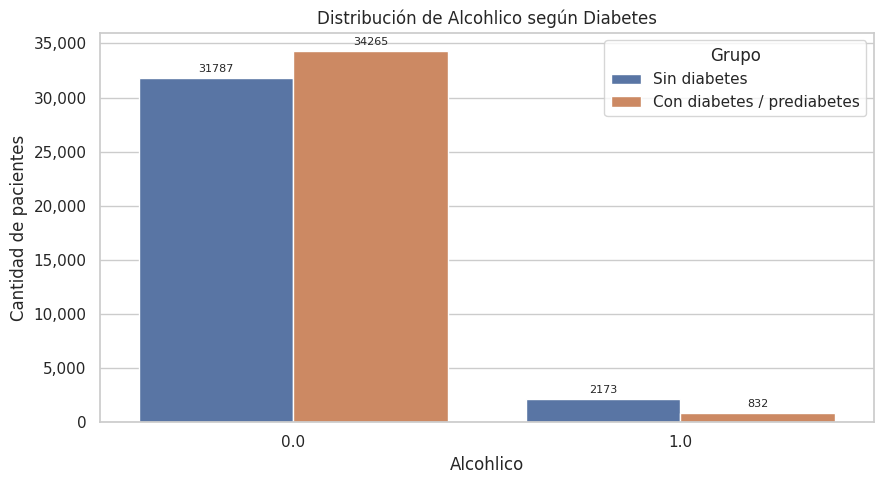

In [47]:
df_plot = tabla_Alcohlico.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de Alcohlico según Diabetes')
plt.xlabel('Alcohlico')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `Alcohlico` es No (93.6%), mientras que en el grupo con diabetes la más frecuente es No (97.6%). La proporción de pacientes en la categoría 'Sí' (o equivalente) es de 6.4% en el grupo sin diabetes frente a 2.4% en el grupo con diabetes, lo que evidencia una diferencia entre ambos grupos.

**Prueba de independencia (chi-cuadrado)**

In [48]:
tabla_chi = pd.crosstab(df['Alcohlico'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 671.8886
p-valor:        3.8805e-148
Grados de libertad: 1
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `Alcohlico` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(1)}$ = 671.89, p-valor < 0.001).

### Variable `eps` (cobertura de salud (EPS o seguro médico))

**Tabla de frecuencias por grupo**

In [49]:
tabla_eps = (
    df.groupby(target)['eps']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'eps': 'categoria'})
)
tabla_eps['porcentaje'] = tabla_eps.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_eps = tabla_eps.sort_values([target, 'n'], ascending=[True, False])
tabla_eps

,Diabetes,categoria,n,porcentaje
0,0.0,1.0,32199,94.81
1,0.0,0.0,1761,5.19
2,1.0,1.0,33675,95.95
3,1.0,0.0,1422,4.05


**Gráfico de barras agrupadas**

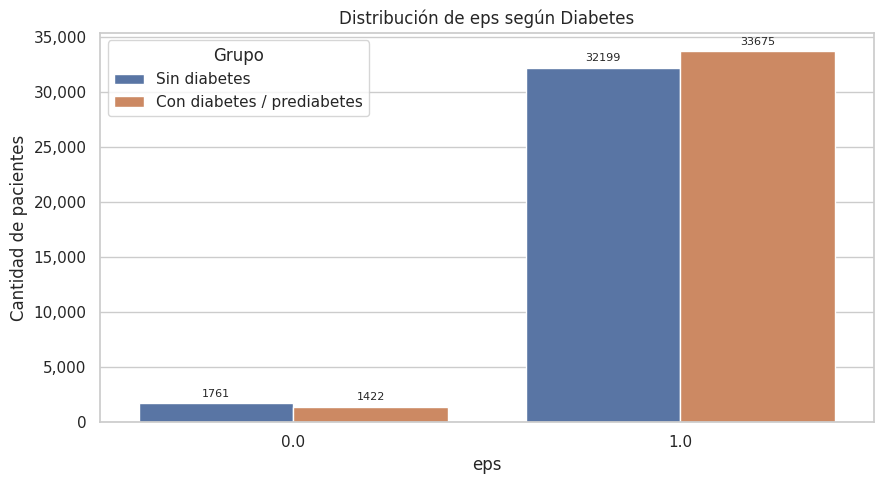

In [50]:
df_plot = tabla_eps.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de eps según Diabetes')
plt.xlabel('eps')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `eps` es Sí (94.8%), mientras que en el grupo con diabetes la más frecuente es Sí (96.0%). La proporción de pacientes en la categoría 'Sí' (o equivalente) es de 94.8% en el grupo sin diabetes frente a 96.0% en el grupo con diabetes, lo que evidencia una diferencia entre ambos grupos.

**Prueba de independencia (chi-cuadrado)**

In [51]:
tabla_chi = pd.crosstab(df['eps'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 50.2123
p-valor:        1.3798e-12
Grados de libertad: 1
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `eps` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(1)}$ = 50.21, p-valor < 0.001).

### Variable `AfordabilidadMedica` (no poder costear una consulta médica por dinero en el último año)

**Tabla de frecuencias por grupo**

In [52]:
tabla_AfordabilidadMedica = (
    df.groupby(target)['AfordabilidadMedica']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'AfordabilidadMedica': 'categoria'})
)
tabla_AfordabilidadMedica['porcentaje'] = tabla_AfordabilidadMedica.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_AfordabilidadMedica = tabla_AfordabilidadMedica.sort_values([target, 'n'], ascending=[True, False])
tabla_AfordabilidadMedica

,Diabetes,categoria,n,porcentaje
0,0.0,0.0,31063,91.47
1,0.0,1.0,2897,8.53
2,1.0,0.0,31355,89.34
3,1.0,1.0,3742,10.66


**Gráfico de barras agrupadas**

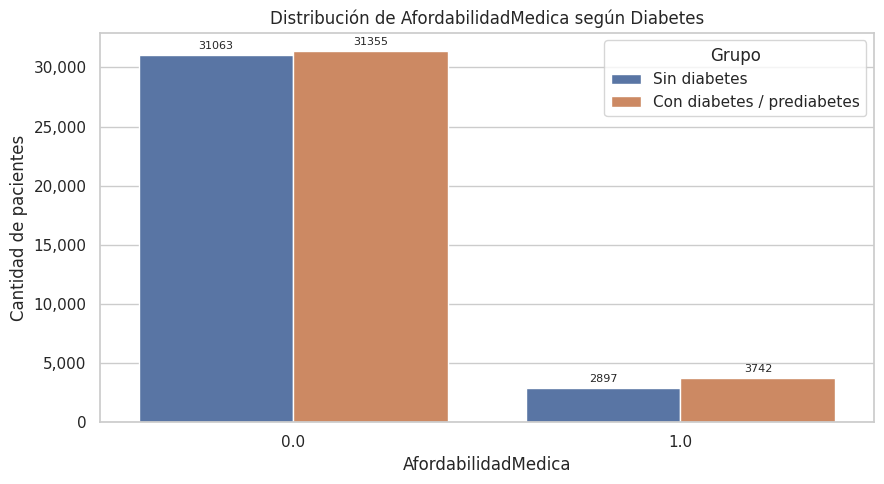

In [53]:
df_plot = tabla_AfordabilidadMedica.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de AfordabilidadMedica según Diabetes')
plt.xlabel('AfordabilidadMedica')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `AfordabilidadMedica` es No (91.5%), mientras que en el grupo con diabetes la más frecuente es No (89.3%). La proporción de pacientes en la categoría 'Sí' (o equivalente) es de 8.5% en el grupo sin diabetes frente a 10.7% en el grupo con diabetes, lo que evidencia una diferencia entre ambos grupos.

**Prueba de independencia (chi-cuadrado)**

In [54]:
tabla_chi = pd.crosstab(df['AfordabilidadMedica'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 89.9751
p-valor:        2.4117e-21
Grados de libertad: 1
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `AfordabilidadMedica` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(1)}$ = 89.98, p-valor < 0.001).

### Variable `SaludG` (salud general percibida)

**Tabla de frecuencias por grupo**

In [55]:
tabla_SaludG = (
    df.groupby(target)['SaludG']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'SaludG': 'categoria'})
)
tabla_SaludG['porcentaje'] = tabla_SaludG.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_SaludG = tabla_SaludG.sort_values([target, 'n'], ascending=[True, False])
tabla_SaludG

,Diabetes,categoria,n,porcentaje
0,0.0,2.0,12825,37.77
1,0.0,3.0,9922,29.22
2,0.0,1.0,6472,19.06
3,0.0,4.0,3511,10.34
4,0.0,5.0,1230,3.62
5,1.0,3.0,13324,37.96
6,1.0,4.0,9781,27.87
7,1.0,2.0,6280,17.89
8,1.0,5.0,4577,13.04
9,1.0,1.0,1135,3.23


**Gráfico de barras agrupadas**

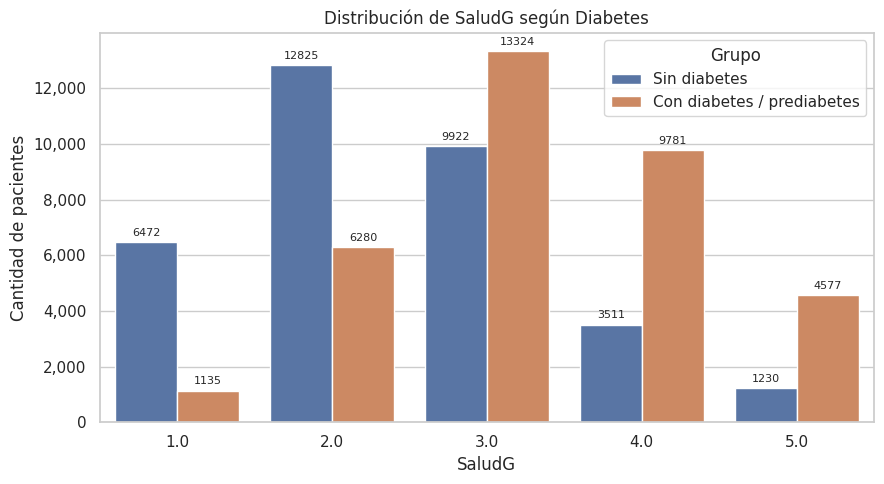

In [56]:
df_plot = tabla_SaludG.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de SaludG según Diabetes')
plt.xlabel('SaludG')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `SaludG` es Muy buena (37.8%), mientras que en el grupo con diabetes la más frecuente es Buena (38.0%). Al comparar ambos grupos se observa un desplazamiento en la distribución de las categorías entre quienes tienen diabetes y quienes no, lo que sugiere una relación entre esta variable ordinal y la condición de diabetes.

**Prueba de independencia (chi-cuadrado)**

In [57]:
tabla_chi = pd.crosstab(df['SaludG'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 11355.5693
p-valor:        0.0000e+00
Grados de libertad: 4
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `SaludG` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(4)}$ = 11355.57, p-valor < 0.001).

### Variable `DificultadCaminar` (dificultad seria para caminar o subir escaleras)

**Tabla de frecuencias por grupo**

In [58]:
tabla_DificultadCaminar = (
    df.groupby(target)['DificultadCaminar']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'DificultadCaminar': 'categoria'})
)
tabla_DificultadCaminar['porcentaje'] = tabla_DificultadCaminar.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_DificultadCaminar = tabla_DificultadCaminar.sort_values([target, 'n'], ascending=[True, False])
tabla_DificultadCaminar

,Diabetes,categoria,n,porcentaje
0,0.0,0.0,29215,86.03
1,0.0,1.0,4745,13.97
2,1.0,0.0,21983,62.63
3,1.0,1.0,13114,37.37


**Gráfico de barras agrupadas**

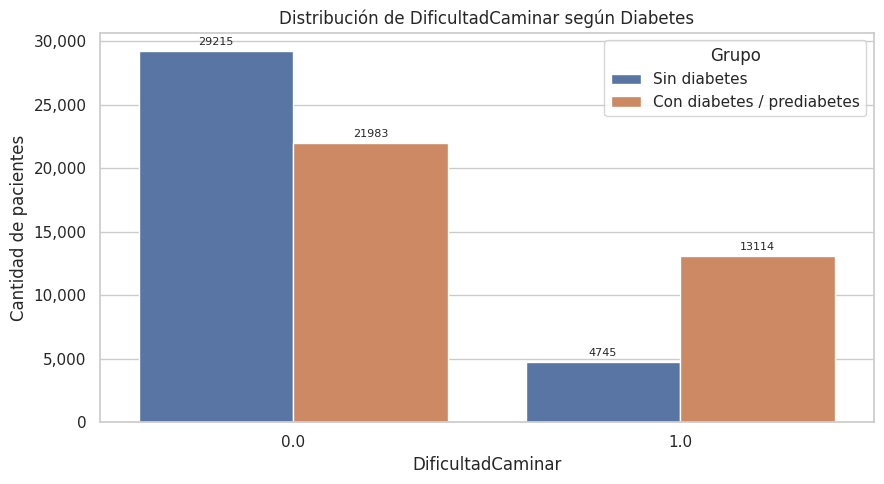

In [59]:
df_plot = tabla_DificultadCaminar.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de DificultadCaminar según Diabetes')
plt.xlabel('DificultadCaminar')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `DificultadCaminar` es No (86.0%), mientras que en el grupo con diabetes la más frecuente es No (62.6%). La proporción de pacientes en la categoría 'Sí' (o equivalente) es de 14.0% en el grupo sin diabetes frente a 37.4% en el grupo con diabetes, lo que evidencia una diferencia entre ambos grupos.

**Prueba de independencia (chi-cuadrado)**

In [60]:
tabla_chi = pd.crosstab(df['DificultadCaminar'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 4924.7961
p-valor:        0.0000e+00
Grados de libertad: 1
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `DificultadCaminar` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(1)}$ = 4924.80, p-valor < 0.001).

### Variable `Genero` (género)

**Tabla de frecuencias por grupo**

In [61]:
tabla_Genero = (
    df.groupby(target)['Genero']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'Genero': 'categoria'})
)
tabla_Genero['porcentaje'] = tabla_Genero.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_Genero = tabla_Genero.sort_values([target, 'n'], ascending=[True, False])
tabla_Genero

,Diabetes,categoria,n,porcentaje
0,0.0,0.0,19190,56.51
1,0.0,1.0,14770,43.49
2,1.0,0.0,18345,52.27
3,1.0,1.0,16752,47.73


**Gráfico de barras agrupadas**

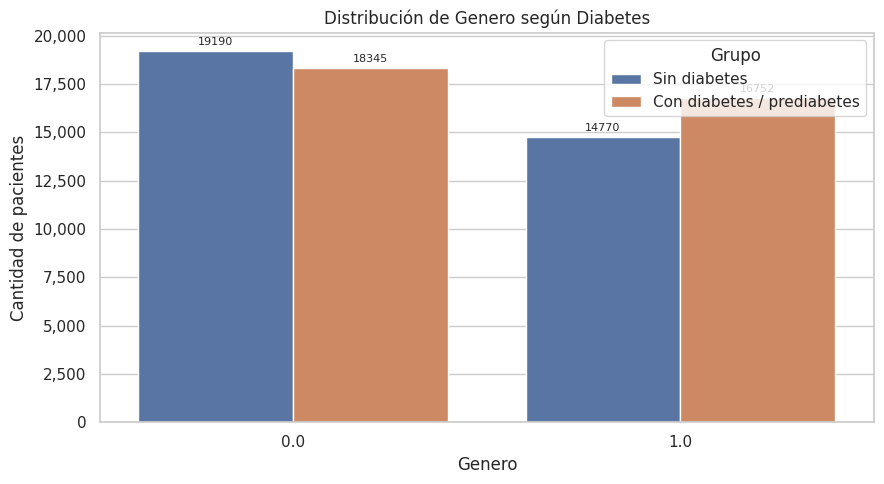

In [62]:
df_plot = tabla_Genero.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de Genero según Diabetes')
plt.xlabel('Genero')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `Genero` es Mujer (56.5%), mientras que en el grupo con diabetes la más frecuente es Mujer (52.3%). La proporción de pacientes en la categoría 'Sí' (o equivalente) es de 43.5% en el grupo sin diabetes frente a 47.7% en el grupo con diabetes, lo que evidencia una diferencia entre ambos grupos.

**Prueba de independencia (chi-cuadrado)**

In [63]:
tabla_chi = pd.crosstab(df['Genero'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 124.7874
p-valor:        5.6651e-29
Grados de libertad: 1
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `Genero` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(1)}$ = 124.79, p-valor < 0.001).

### Variable `Edad` (categoría de edad (rangos de 5 años, de 18 a 80+))

**Tabla de frecuencias por grupo**

In [64]:
tabla_Edad = (
    df.groupby(target)['Edad']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'Edad': 'categoria'})
)
tabla_Edad['porcentaje'] = tabla_Edad.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_Edad = tabla_Edad.sort_values([target, 'n'], ascending=[True, False])
tabla_Edad

,Diabetes,categoria,n,porcentaje
0,0.0,9.0,4192,12.34
1,0.0,8.0,4151,12.22
2,0.0,10.0,4102,12.08
3,0.0,7.0,3555,10.47
4,0.0,11.0,2842,8.37
5,0.0,6.0,2731,8.04
6,0.0,5.0,2338,6.88
7,0.0,13.0,2196,6.47
8,0.0,4.0,2066,6.08
9,0.0,12.0,1975,5.82


**Gráfico de barras agrupadas**

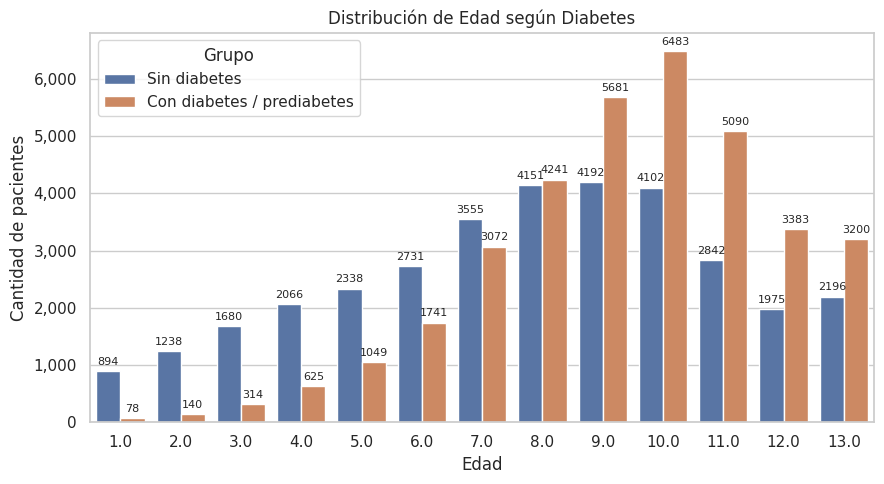

In [65]:
df_plot = tabla_Edad.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de Edad según Diabetes')
plt.xlabel('Edad')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `Edad` es 9 (12.3%), mientras que en el grupo con diabetes la más frecuente es 10 (18.5%). Al comparar ambos grupos se observa un desplazamiento en la distribución de las categorías entre quienes tienen diabetes y quienes no, lo que sugiere una relación entre esta variable ordinal y la condición de diabetes.

**Prueba de independencia (chi-cuadrado)**

In [66]:
tabla_chi = pd.crosstab(df['Edad'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 5950.1989
p-valor:        0.0000e+00
Grados de libertad: 12
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `Edad` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(12)}$ = 5950.20, p-valor < 0.001).

### Variable `Educacion` (nivel educativo alcanzado)

**Tabla de frecuencias por grupo**

In [67]:
tabla_Educacion = (
    df.groupby(target)['Educacion']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'Educacion': 'categoria'})
)
tabla_Educacion['porcentaje'] = tabla_Educacion.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_Educacion = tabla_Educacion.sort_values([target, 'n'], ascending=[True, False])
tabla_Educacion

,Diabetes,categoria,n,porcentaje
0,0.0,6.0,14418,42.46
1,0.0,5.0,9534,28.07
2,0.0,4.0,8365,24.63
3,0.0,3.0,1151,3.39
4,0.0,2.0,464,1.37
5,0.0,1.0,28,0.08
6,1.0,4.0,11032,31.43
7,1.0,5.0,10311,29.38
8,1.0,6.0,10228,29.14
9,1.0,3.0,2296,6.54


**Gráfico de barras agrupadas**

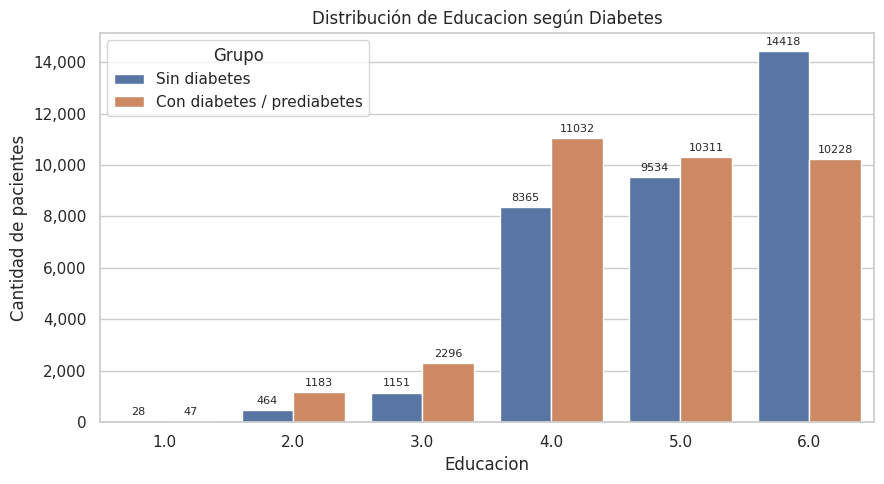

In [68]:
df_plot = tabla_Educacion.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de Educacion según Diabetes')
plt.xlabel('Educacion')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `Educacion` es Universitario graduado (42.5%), mientras que en el grupo con diabetes la más frecuente es Secundaria completa (31.4%). Al comparar ambos grupos se observa un desplazamiento en la distribución de las categorías entre quienes tienen diabetes y quienes no, lo que sugiere una relación entre esta variable ordinal y la condición de diabetes.

**Prueba de independencia (chi-cuadrado)**

In [69]:
tabla_chi = pd.crosstab(df['Educacion'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 1790.2500
p-valor:        0.0000e+00
Grados de libertad: 5
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `Educacion` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(5)}$ = 1790.25, p-valor < 0.001).

### Variable `Ingresos` (nivel de ingresos anual del hogar)

**Tabla de frecuencias por grupo**

In [70]:
tabla_Ingresos = (
    df.groupby(target)['Ingresos']
    .value_counts()
    .reset_index(name='n')
    .rename(columns={'Ingresos': 'categoria'})
)
tabla_Ingresos['porcentaje'] = tabla_Ingresos.groupby(target)['n'].transform(lambda x: (x / x.sum()) * 100).round(2)
tabla_Ingresos = tabla_Ingresos.sort_values([target, 'n'], ascending=[True, False])
tabla_Ingresos

,Diabetes,categoria,n,porcentaje
0,0.0,8.0,12265,36.12
1,0.0,7.0,6048,17.81
2,0.0,6.0,4935,14.53
3,0.0,5.0,3486,10.27
4,0.0,4.0,2599,7.65
5,0.0,3.0,1988,5.85
6,0.0,2.0,1411,4.15
7,0.0,1.0,1228,3.62
8,1.0,8.0,7042,20.06
9,1.0,6.0,5260,14.99


**Gráfico de barras agrupadas**

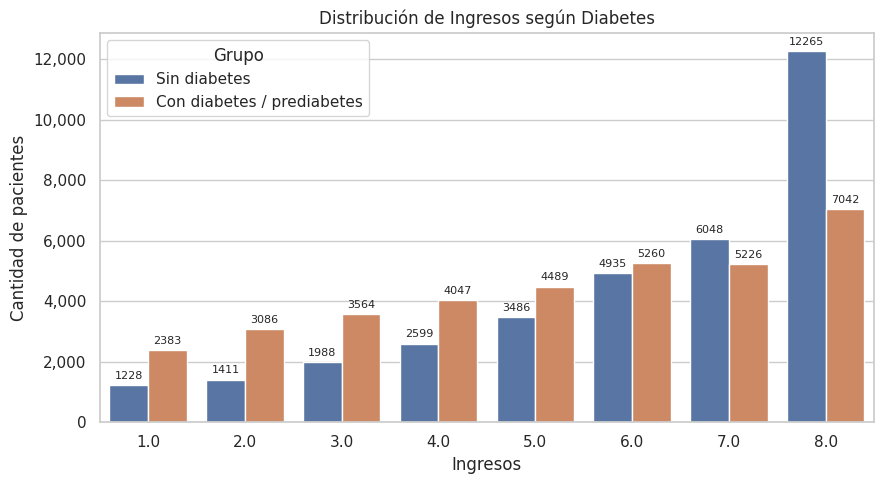

In [71]:
df_plot = tabla_Ingresos.copy()
df_plot['grupo'] = df_plot[target].map(etiquetas_diabetes)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x='categoria', y='n', hue='grupo', data=df_plot,
                  palette=['#4C72B0', '#DD8452'], dodge=True)

for container in ax.containers:
    grupo_lbl = container.get_label()
    porcentajes = df_plot.loc[df_plot['grupo'] == grupo_lbl, 'porcentaje'].values
    labels = [f"{int(v):,} ({p:.1f}%)" for v, p in zip(container.datavalues, porcentajes)]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.title('Distribución de Ingresos según Diabetes')
plt.xlabel('Ingresos')
plt.ylabel('Cantidad de pacientes')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

En el grupo sin diabetes, la categoría más frecuente de `Ingresos` es >= $75,000 (36.1%), mientras que en el grupo con diabetes la más frecuente es >= $75,000 (20.1%). Al comparar ambos grupos se observa un desplazamiento en la distribución de las categorías entre quienes tienen diabetes y quienes no, lo que sugiere una relación entre esta variable ordinal y la condición de diabetes.

**Prueba de independencia (chi-cuadrado)**

In [72]:
tabla_chi = pd.crosstab(df['Ingresos'], df[target])
chi2, p, dof, expected = chi2_contingency(tabla_chi)

print(f"Estadístico X²: {chi2:.4f}")
print(f"p-valor:        {p:.4e}")
print(f"Grados de libertad: {dof}")
print(f"Resultado: {'Rechaza H0 (dependientes)' if p < 0.05 else 'No rechaza H0 (independientes)'}")

Estadístico X²: 3347.7424
p-valor:        0.0000e+00
Grados de libertad: 7
Resultado: Rechaza H0 (dependientes)


Se rechaza H0: la prueba chi-cuadrado indica que `Ingresos` y `Diabetes` son estadísticamente **dependientes** ($\chi^2_{(7)}$ = 3347.74, p-valor < 0.001).

## 4. Conclusión

El análisis bivariado confirma que la condición de diabetes está asociada, de manera estadísticamente significativa, con todas las variables numéricas y categóricas evaluadas. Entre las variables numéricas, el índice de masa corporal (`IMC`) muestra la diferencia más clara entre grupos: los pacientes con diabetes presentan, en promedio, un IMC (32.0) considerablemente mayor que los pacientes sin diabetes (27.9). Las variables `SaludM` y `SaludF`, que reflejan días de salud mental y física percibida como no buena, también son mayores en el grupo con diabetes, aunque con distribuciones muy concentradas en cero y colas largas, lo que llevó a usar pruebas no paramétricas (Mann-Whitney) tras confirmar la ausencia de normalidad con Anderson-Darling.

En cuanto a las variables categóricas, condiciones de salud como presión arterial alta, colesterol alto, enfermedad coronaria, derrame cerebral y dificultad para caminar muestran proporciones notablemente mayores en el grupo con diabetes, así como una peor percepción de salud general (`SaludG`). De igual forma, variables sociodemográficas como edad, nivel educativo e ingresos muestran patrones diferenciados entre ambos grupos: la diabetes tiende a concentrarse en categorías de mayor edad y de menor nivel educativo e ingresos. Todas las pruebas chi-cuadrado resultaron significativas (p < 0.05), lo que indica que ninguna de las variables categóricas analizadas es independiente de la condición de diabetes en este conjunto de datos.